Test

In [1]:
import numpy as np
import scipy.stats as scp
import numpy.random as rnd
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
states = np.arange(0,11,1)

In [4]:
statetransitions = np.zeros((len(states),len(states)))
statetransitions[0][0] = 0.9
statetransitions[0][1] = 0.1
statetransitions[10][-1] = 0.9
statetransitions[10][-2] = 0.1

for i in range(len(states)-2):
        
    statetransitions[i+1][0] = 0.1
    statetransitions[i+1][1] = 0.8
    statetransitions[i+1][2] = 0.1
    statetransitions[i+1] = np.roll(statetransitions[i+1],i)
    

In [5]:
statetransitions

array([[0.9, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9]])

In [6]:
cumstatetransitions = np.cumsum(statetransitions,axis=1)

In [7]:
cumstatetransitions

array([[0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 1. ]])

In [17]:
numexperiments = 10
numtimesteps = 50

In [ ]:

posarr = np.zeros([numexperiments,numtimesteps])
posarr[:,0] = 1

for experiment in range(numexperiments):
    rand = rnd.uniform(low=0,high=1,size=numtimesteps)
    for currenttime in range(1,numtimesteps):
        for state in range(len(statetransitions)):
            lastposition = int(posarr[experiment,currenttime-1])
            if rand[currenttime] < cumstatetransitions[lastposition][state]:
                posarr[experiment,currenttime] = state
                break
posarr = np.transpose(posarr)


Text(0.5, 0.98, '10 Random walks')

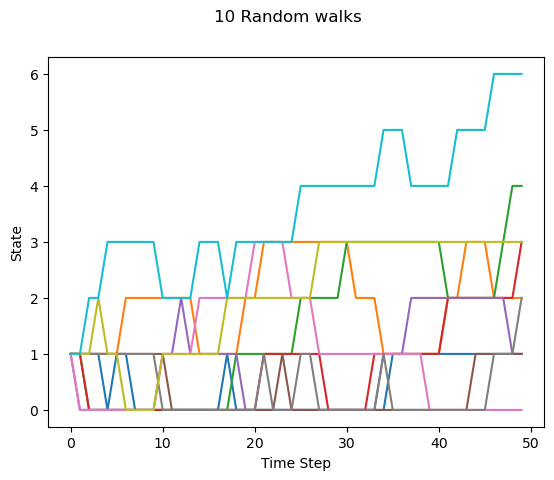

In [88]:
fig, ax = plt.subplots()
ax.plot(posarr)
ax.set_xlabel("Time Step")
ax.set_ylabel("State")
fig.suptitle("10 Random walks")